##Stock Price Prediction

In [1]:
pip install yfinance scikit-learn matplotlib pandas

Import Libraries

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Load Stock Data

In [3]:
stock = yf.download('AAPL', start='2022-01-01', end='2024-01-01')

print(stock.head())

/tmp/ipykernel_1702/1027004986.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download('AAPL', start='2022-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  177.939728  178.790282  173.735900  173.853212  104487900
2022-01-04  175.681366  178.848915  175.114335  178.545850   99310400
2022-01-05  171.008270  176.140865  170.734533  175.593390   94537600
2022-01-06  168.153580  171.379785  167.801630  168.837923   96904000
2022-01-07  168.319763  170.245709  167.205258  169.023663   86709100


Select Features

In [4]:
features = stock[['Open', 'High', 'Low', 'Volume']]
target = stock['Close']

Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Train Model

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Predictions

In [7]:
predictions = model.predict(X_test)

Model Evaluation

In [8]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.8239126347864063


Plot Actual vs Predicted

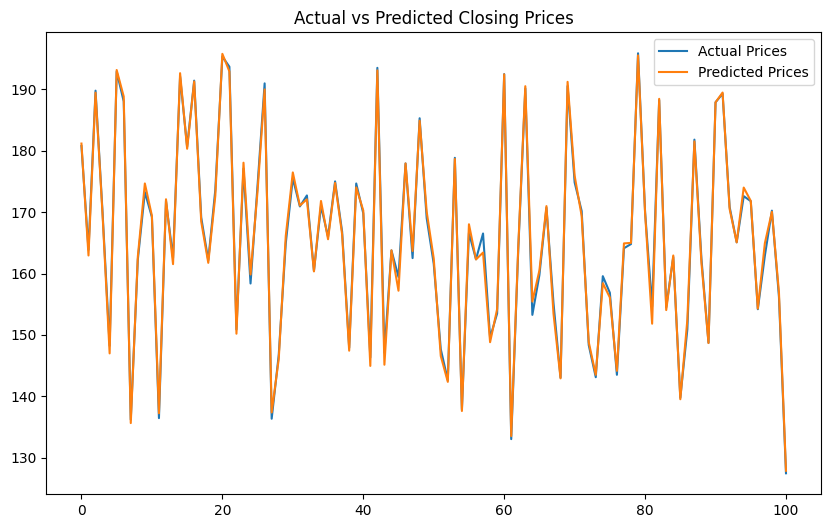

In [9]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices')

plt.legend()
plt.title("Actual vs Predicted Closing Prices")

plt.show()